In [6]:
import numpy as np
import pandas as pd
from scipy.optimize import minimize
import matplotlib.pyplot as plt

In [7]:
class BradleyTerryElasticNet:
    def __init__(self,
                 lambda_s=1e-2, lambda_a=1e-2,
                 lambda_b=1e-2, rho_b=0.2,
                 lambda_g=1e-2, rho_g=0.2,
                 eps=1e-6):
        self.lambda_s = lambda_s
        self.lambda_a = lambda_a
        self.lambda_b, self.rho_b = lambda_b, rho_b
        self.lambda_g, self.rho_g = lambda_g, rho_g
        self.eps = eps
        self.history_alpha = []
        self.fitted = False

    # ----- ElasticNet helper -----
    def _elasticnet(self, theta, lam, rho):
        l1 = np.sqrt(theta**2 + self.eps)
        reg = lam * (((1 - rho)/2)*np.sum(theta**2) + rho*np.sum(l1))
        grad = lam * ((1 - rho)*theta + rho*theta/np.sqrt(theta**2 + self.eps))
        return reg, grad

    # ----- Fit -----
    def fit(self, home_idx, away_idx, y, X, Z, team_names,
            maxiter=500, verbose=False):
        m = len(team_names)
        p, q = X.shape[1], Z.shape[1]
        s = np.zeros(m); a = np.zeros(m)
        b = np.zeros(p); g = np.zeros(q)

        def loss_grad(xvec):
            s = xvec[:m]; a = xvec[m:2*m]
            b = xvec[2*m:2*m+p]; g = xvec[2*m+p:]
            z = (s[home_idx] - s[away_idx]) + a[home_idx]
            if p: z += X @ b
            if q: z += Z @ g
            pred = 1 / (1 + np.exp(-z))
            err = y - pred

            loss = -np.sum(
                y*np.log(pred+1e-12) + (1-y)*np.log(1-pred+1e-12)
            )
            grad_s = np.zeros_like(s)
            np.add.at(grad_s, home_idx, -err)
            np.add.at(grad_s, away_idx, err)
            grad_a = np.zeros_like(a)
            np.add.at(grad_a, home_idx, -err)
            grad_b = -(X.T @ err) if p else np.array([])
            grad_g = -(Z.T @ err) if q else np.array([])

            # regularization
            loss += 0.5*self.lambda_s*np.sum(s**2); grad_s += self.lambda_s*s
            loss += 0.5*self.lambda_a*np.sum(a**2); grad_a += self.lambda_a*a
            rb, gb = self._elasticnet(b, self.lambda_b, self.rho_b)
            rg, gg = self._elasticnet(g, self.lambda_g, self.rho_g)
            loss += rb + rg; grad_b += gb; grad_g += gg

            # identifiability
            s -= s.mean(); a -= a.mean()
            grad_s -= grad_s.mean(); grad_a -= grad_a.mean()
            grad = np.concatenate([grad_s, grad_a, grad_b, grad_g])
            return loss, grad

        def callback(xk):
            self.history_alpha.append(xk[m:2*m].copy())

        x0 = np.concatenate([s, a, b, g])
        res = minimize(
            loss_grad, x0, jac=True, callback=callback,
            method="L-BFGS-B",
            options=dict(maxiter=maxiter, disp=verbose)
        )

        s, a, b, g = np.split(res.x, [m, 2*m, 2*m+p])
        self.s, self.alpha_team = s - s.mean(), a - a.mean()
        self.beta, self.gamma = b, g
        self.team_names = team_names
        self.fitted = True
        self.result = res
        return self

    # ----- Predict probabilities -----
    def predict_proba(self, home_idx, away_idx, X, Z):
        z = (self.s[home_idx] - self.s[away_idx]) + self.alpha_team[home_idx]
        if X.size: z += X @ self.beta
        if Z.size: z += Z @ self.gamma
        return 1 / (1 + np.exp(-z))

    # ----- Evaluate (added inside class) -----
    def evaluate(self, df, team_to_idx, feature_cols, context_cols,
                 mu, sd, mu_context, sd_context):
        """Compute accuracy & avg log‑likelihood for any dataset."""
        home_idx = np.array([team_to_idx[t] for t in df["home_abbr"]], int)
        away_idx = np.array([team_to_idx[t] for t in df["away_abbr"]], int)
        y_true = df["home_win"].astype(float).values

        if feature_cols:
            X = (df[feature_cols].astype(float).values - mu) / sd
        else:
            X = np.zeros((len(df), 0))
        if context_cols:
            Z = (df[context_cols].astype(float).values - mu_context) / sd_context
        else:
            Z = np.zeros((len(df), 0))

        p_hat = self.predict_proba(home_idx, away_idx, X, Z)
        acc = np.mean((p_hat >= 0.5) == y_true)
        ll  = np.mean(y_true*np.log(p_hat+1e-12)
                      + (1-y_true)*np.log(1-p_hat+1e-12))
        return acc, ll

    # ----- Alpha evolution plot -----
    def plot_alpha_history(self):
        if not self.history_alpha:
            print("No α_HCA history recorded.")
            return
        hist = np.array(self.history_alpha)
        plt.figure(figsize=(8,5))
        for i, name in enumerate(self.team_names):
            plt.plot(hist[:, i], label=name)
        plt.legend(); plt.title("Team‑specific α_HCA evolution")
        plt.xlabel("Iteration"); plt.ylabel("α value")
        plt.tight_layout(); plt.show()

    def plot_train_test_metrics(self):
        """Plot train & validation accuracy collected during fit."""
        if not self.metrics_history:
            print("No metrics were recorded (provide test data to fit).")
            return
        data = np.array(self.metrics_history)
        iters, acc_tr, acc_val = data[:,0], data[:,1], data[:,2]
        plt.figure(figsize=(7,4))
        plt.plot(iters, acc_tr, label="Train accuracy", color="tab:blue")
        plt.plot(iters, acc_val, label="Test accuracy", color="tab:orange")
        plt.xlabel("Iteration"); plt.ylabel("Accuracy")
        plt.legend(); plt.title("Train vs Test accuracy during fitting")
        plt.grid(alpha=0.3); plt.tight_layout(); plt.show()

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:122: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  plt.tight_layout(); plt.show()



================ RESULTS ================
Train → acc=0.6471, log‑likelihood=-0.628061
Test  → acc=0.6114, log‑likelihood=-0.660271

Team‑specific home‑court advantages (α_HCA):
PHI    α= 0.4063
SAS    α= 0.3891
POR    α= 0.3099
DET    α= 0.2004
DEN    α= 0.1962
WAS    α= 0.1791
ATL    α= 0.1371
CLE    α= 0.1071
UTA    α= 0.0891
IND    α= 0.0790
MEM    α= 0.0740
MIL    α= 0.0534
NOP    α= 0.0393
OKC    α= 0.0356
CHA    α=-0.0090
MIN    α=-0.0541
MIA    α=-0.0591
ORL    α=-0.0596
TOR    α=-0.0955
DAL    α=-0.1044
HOU    α=-0.1067
GSW    α=-0.1315
NYK    α=-0.1389
BKN    α=-0.1515
LAC    α=-0.1749
BOS    α=-0.1857
CHI    α=-0.1916
LAL    α=-0.2034
SAC    α=-0.2945
PHX    α=-0.3351


C:\Users\hosiu\AppData\Local\Programs\Python\Python313\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8209 (\N{NON-BREAKING HYPHEN}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


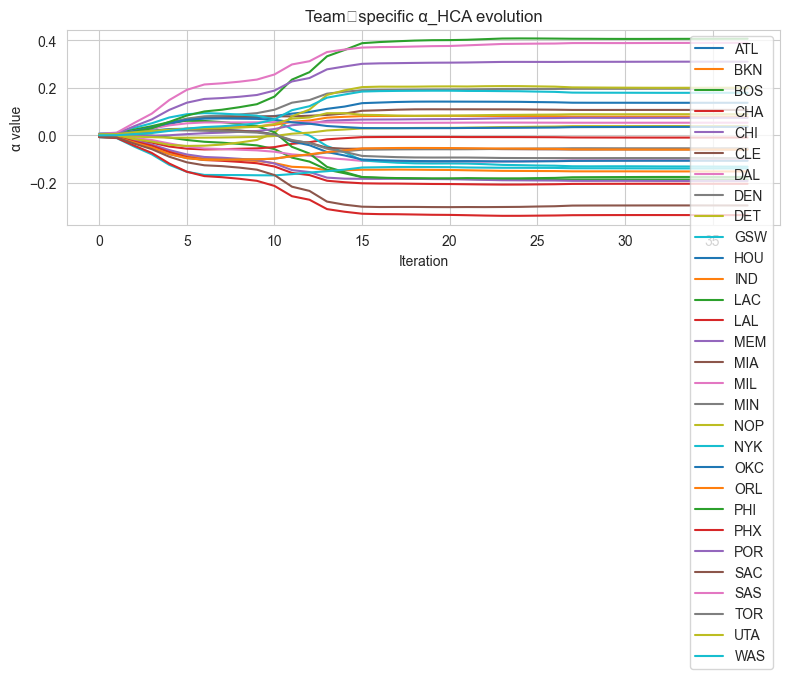

In [8]:
# --- Load and filter your dataset ---
df = pd.read_csv('./data/bt_games_cleaned.csv')
df = df[df["Game_Type"] == "regular"].copy()

context_cols = ["home_b2b", "away_b2b", "home_rest_days", "away_rest_days", "rest_diff"]
feature_cols = ["diff_recent_margin", "diff_recent_win_pct", "diff_pts_pg_to_date", "split_win_pct_delta"]

train = df[df["split"] == "train"].copy()
test  = df[df["split"] == "test"].copy()

# --- Encode teams ---
teams = sorted(pd.unique(pd.concat([train["home_abbr"], train["away_abbr"]], ignore_index=True)))
team_to_idx = {t: i for i, t in enumerate(teams)}

home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], int)
away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], int)
y = train["home_win"].astype(float).values
n = len(y)

# --- Standardize features ---
if feature_cols:
    X_raw = train[feature_cols].astype(float).values
    mu = X_raw.mean(0); sd = X_raw.std(0); sd[sd == 0] = 1
    X = (X_raw - mu) / sd
else:
    X = np.zeros((n, 0)); mu, sd = np.array([]), np.array([])

if context_cols:
    Z_raw = train[context_cols].astype(float).values
    mu_context = Z_raw.mean(0); sd_context = Z_raw.std(0); sd_context[sd_context == 0] = 1
    Z = (Z_raw - mu_context) / sd_context
else:
    Z = np.zeros((n, 0)); mu_context, sd_context = np.array([]), np.array([])

# ===============================================================
# --- Fit model using training data -----------------------------
# ===============================================================
model = BradleyTerryElasticNet(
    lambda_s=1e-4, lambda_a=1e-4,
    lambda_b=5e-4, rho_b=0.15,
    lambda_g=5e-4, rho_g=0.15
)

model.fit(home_idx, away_idx, y, X, Z, teams, maxiter=500, verbose=True)

# ===============================================================
# --- Evaluate on train and test sets ----------------------------
# ===============================================================
tr_acc, tr_ll = model.evaluate(train, team_to_idx, feature_cols,
                               context_cols, mu, sd, mu_context, sd_context)
t_acc, t_ll  = model.evaluate(test, team_to_idx, feature_cols,
                              context_cols, mu, sd, mu_context, sd_context)

print("\n================ RESULTS ================")
print(f"Train → acc={tr_acc:.4f}, log‑likelihood={tr_ll:.6f}")
print(f"Test  → acc={t_acc:.4f}, log‑likelihood={t_ll:.6f}")

# Display learned α_HCA
alpha_sorted = sorted(zip(teams, model.alpha_team), key=lambda x: -x[1])
print("\nTeam‑specific home‑court advantages (α_HCA):")
for name, a in alpha_sorted:
    print(f"{name:<5s}  α={a: .4f}")

# Optionally visualize α dynamics
model.plot_alpha_history()

In [9]:
from itertools import product

def search_hyperparams(train, test, team_to_idx,
                       feature_cols, context_cols,
                       mu, sd, mu_context, sd_context,
                       teams,
                       param_grid, maxiter=250):
    """
    Train and evaluate across grid of parameters.
    Returns the best model and accuracy table.
    """

    home_idx = np.array([team_to_idx[t] for t in train["home_abbr"]], int)
    away_idx = np.array([team_to_idx[t] for t in train["away_abbr"]], int)
    y = train["home_win"].astype(float).values

    X = (train[feature_cols].astype(float).values - mu) / sd if feature_cols else np.zeros((len(train), 0))
    Z = (train[context_cols].astype(float).values - mu_context) / sd_context if context_cols else np.zeros((len(train), 0))

    best_acc = -np.inf
    best_params = None
    best_model = None
    results = []

    # Create Cartesian product of hyperparameter values
    keys, values = zip(*param_grid.items())
    for combo in product(*values):
        params = dict(zip(keys, combo))
        print(f"\n==== Training {params} ====")

        model = BradleyTerryElasticNet(**params)
        model.fit(home_idx, away_idx, y, X, Z, teams, maxiter=maxiter, verbose=False)

        acc_train, ll_train = model.evaluate(train, team_to_idx,
                                             feature_cols, context_cols,
                                             mu, sd, mu_context, sd_context)
        acc_test, ll_test = model.evaluate(test, team_to_idx,
                                           feature_cols, context_cols,
                                           mu, sd, mu_context, sd_context)

        results.append({**params,
                        "train_acc": acc_train, "train_ll": ll_train,
                        "test_acc": acc_test, "test_ll": ll_test})

        if acc_test > best_acc:
            best_acc = acc_test
            best_params = params
            best_model = model

        print(f"Train acc={acc_train:.4f}, Test acc={acc_test:.4f}")

    print("\n=== Best parameter set ===")
    print(best_params, f"→ test_acc={best_acc:.4f}")
    return best_model, pd.DataFrame(results), best_params

In [10]:
param_grid = {
    "lambda_s": [1e-4, 1e-3],
    "lambda_a": [1e-4, 1e-3],
    "lambda_b": [1e-3, 1e-2],
    "rho_b":   [0.1, 0.2],
    "lambda_g": [1e-3, 1e-2],
    "rho_g":   [0.1, 0.2]
}
best_model, results_df, best_params = search_hyperparams(
    train, test, team_to_idx,
    feature_cols, context_cols,
    mu, sd, mu_context, sd_context,
    teams, param_grid, maxiter=250
)

# summary table
print(results_df.sort_values("test_acc", ascending=False).head())

# Evaluate final best model
tr_acc, tr_ll = best_model.evaluate(train, team_to_idx, feature_cols, context_cols, mu, sd, mu_context, sd_context)
te_acc, te_ll = best_model.evaluate(test, team_to_idx, feature_cols, context_cols, mu, sd, mu_context, sd_context)
print(f"\nOptimal → Train acc={tr_acc:.4f}, Test acc={te_acc:.4f}")

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(



==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.01, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.01, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarni

Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.1, 'lambda_g': 0.01, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.1, 'lambda_g': 0.01, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Tr

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarni

...

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarni

Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.01, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.01, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.001, 'rho_b': 0.2, 'lambda_g': 0.01, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.01, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6114

==== Training {

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(


Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.001, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6114

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.01, 'rho_g': 0.1} ====
Train acc=0.6471, Test acc=0.6117

==== Training {'lambda_s': 0.001, 'lambda_a': 0.001, 'lambda_b': 0.01, 'rho_b': 0.2, 'lambda_g': 0.01, 'rho_g': 0.2} ====
Train acc=0.6471, Test acc=0.6117

=== Best parameter set ===
{'lambda_s': 0.0001, 'lambda_a': 0.0001, 'lambda_b': 0.001, 'rho_b': 0.1, 'lambda_g': 0.001, 'rho_g': 0.2} → test_acc=0.6117
   lambda_s  lambda_a  lambda_b  rho_b  lambda_g  rho_g  train_acc  train_ll  \
1    0.0001    0.0001     0.001    0.1     0.001    0.2   0.647123 -0.628061   
2    0.0001    0.0001  

C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
C:\Users\hosiu\AppData\Local\Temp\ipykernel_37428\3473573591.py:67: DeprecationWarning: scipy.optimize: The `disp` and `iprint` options of the L-BFGS-B solver are deprecated and will be removed in SciPy 1.18.0.
  res = minimize(
